# Archetype 7 — Base + PV + Electric Vehicle (EV)

## Purpose

Computes the annual TCoE for **Archetype 7: Base + PV (10 kWp) + EV** across 3 strategies x 7 DSOs -> **21 runs**.

PV surplus is allocated to base load first (must-run). Remaining surplus can cover EV charging, reducing the EV grid import that §14a billing applies to. This adds a solar self-consumption dimension on top of Archetype 5 (Base + EV).

| Strategy | Flexible resource | Signal |
|---|---|---|
| **no_flex** | None — greedy rule-based charging; PV offsets base then EV | none |
| **dt_flex** | LP shifts EV charging | spot (ct/kWh) on net site import |
| **tcoe_flex** | LP per DSO x §14a option | spot + DSO EV-rate + levies on EV grid import |

**§14a applies to EV grid import only** (after PV self-use). PV export earns the spot price.

## Input files (`inputs/`)

| File | Content |
|---|---|
| `base_demand_h25_4500kwh_2026_15min.csv` | BDEW H25 base demand (kWh/slot) |
| `pv_kassel_10kwp_2026_15min.csv` | 10 kWp PV generation Kassel 2026 (kWh/slot) |
| `ev_profile_representative_50kwh_11kw_2026_15min.csv` | EV availability + driving demand profile |
| `ev_parameters_representative_50kwh_11kw_2026.csv` | EV sizing and SoC parameters |
| `spot_prices_de_lu_2025_15min.csv` | Day-ahead spot price (ct/kWh) |
| `dso_tariffs_residential_2026.csv` | Residential base tariffs + §14a module parameters |
| `dso_mod3_timebands_2026.csv` | §14a Modul 3 HT/NT/ST timeband rules per DSO |
| `residential_taxes_2026.csv` | German levies (ct/kWh, pre-VAT) |

## Output (`outputs/`)

`results_base_pv_ev_2026.csv` — 21 rows x cost-component columns.

## Billing convention

Net spot cost (import x spot - feedin x spot). DSO volumetric split: base import at standard Arbeitspreis; EV grid import at §14a option rate. Single 19% VAT on full net subtotal.

## Solver

Gurobi via PuLP. LP (continuous) at 15-min resolution (T = 35,040). Max 7 x 3 = 21 LP solves for `tcoe_flex`.

## Thesis reference

Chapter 5, Section 5.1 — Results: Archetype 7 (Base + PV + EV)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pulp
from pathlib import Path

os.environ['GRB_LICENSE_FILE'] = os.path.expanduser('~/gurobi.lic')

def find_repo_root(marker='README.md'):
    p = Path('__file__').resolve().parent
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f'Repo root (containing {marker}) not found.')

REPO_ROOT = find_repo_root()
INPUTS    = REPO_ROOT / 'inputs'
OUTPUTS   = REPO_ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print(f'Repo root : {REPO_ROOT}')


Repo root : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub


## Step 1 — Load inputs and EV parameters

In [2]:
# Base demand (H25)
base_demand = pd.read_csv(INPUTS / 'base_demand_h25_4500kwh_2026_15min.csv',
                          parse_dates=['timestamp'])

# PV generation — 'datetime' column in this file; rename for internal consistency
pv_df = pd.read_csv(INPUTS / 'pv_kassel_10kwp_2026_15min.csv',
                    parse_dates=['datetime'])
pv_df = pv_df.rename(columns={'datetime': 'timestamp', 'energy_kWh': 'pv_kWh'})

# EV profile — 'local_time' column; rename for internal consistency
ev_profile = pd.read_csv(INPUTS / 'ev_profile_representative_50kwh_11kw_2026_15min.csv',
                         parse_dates=['local_time'])
ev_profile = ev_profile.rename(columns={'local_time': 'timestamp'})

# Spot prices
spot = pd.read_csv(INPUTS / 'spot_prices_de_lu_2025_15min.csv',
                   parse_dates=['timestamp'])

# Merge all onto a single aligned index
df = (base_demand
      .merge(pv_df[['timestamp', 'pv_kWh']], on='timestamp')
      .merge(ev_profile[['timestamp', 'f_avail', 'E_EV_demand_kWh']], on='timestamp')
      .merge(spot[['timestamp', 'price_ct_kWh']], on='timestamp'))
df['price_ct_kWh'] = df['price_ct_kWh'].ffill().bfill()
n = len(df)

# EV parameters
ev_params = pd.read_csv(INPUTS / 'ev_parameters_representative_50kwh_11kw_2026.csv',
                        index_col='parameter')['value']
ev_p = {k: float(v) for k, v in ev_params.items()}
E_EV_max  = ev_p['E_EV_max_kWh']
P_EV_max  = ev_p['P_EV_max_ch_kW']
eta_EV    = ev_p['eta_EV_charge']
q_loss_EV = ev_p['q_losses_EV']
E_min_dep = ev_p['E_min_departure_kWh']
E_min_ch  = ev_p['E_min_charge_kWh']

# Levies and tariffs
taxes       = pd.read_csv(INPUTS / 'residential_taxes_2026.csv')
TAX_PRE_VAT = float(taxes.loc[taxes['region'] == 'DE', 'Total_no_VAT_ct_kWh'].iloc[0])
dso_tariffs = pd.read_csv(INPUTS / 'dso_tariffs_residential_2026.csv')
SMART_OP_EUR = 100.0
VAT_RATE     = 0.19

# Core arrays
dt_h     = 0.25
q_base   = df['demand_kwh'].values
pv_arr   = df['pv_kWh'].values
f_avail  = df['f_avail'].values
E_dem    = df['E_EV_demand_kWh'].values
spot_arr = df['price_ct_kWh'].values

# PV allocation (base first): base import is fixed; surplus is available to offset EV charging
pv_to_base  = np.minimum(pv_arr, q_base)
base_import = q_base - pv_to_base    # base grid import per slot (fixed, not a decision variable)
pv_surplus  = pv_arr - pv_to_base    # PV remaining after base self-consumption

# No-flex: greedy rule-based charging
soc_nf    = np.zeros(n + 1)
soc_nf[0] = E_min_ch                 # initialise at comfort floor
P_ev_nf   = np.zeros(n)

for t in range(n):
    if f_avail[t] > 0.5 and soc_nf[t] < E_min_dep:  # home AND below departure threshold -> charge
        P_ev_nf[t] = P_EV_max
    soc_nf[t+1] = np.clip(
        (1 - q_loss_EV * dt_h) * soc_nf[t]  # standby loss
        + eta_EV * P_ev_nf[t] * dt_h         # energy stored (net of charging loss eta)
        - E_dem[t],                           # driving withdrawal (away slots)
        0, E_EV_max
    )

# EV site energy = AC energy drawn by charger; grid import = site - PV surplus used for EV
E_ev_site_nf  = P_ev_nf * dt_h / eta_EV          # [kWh/slot] total AC energy consumed
E_ev_grid_nf  = np.maximum(0.0, E_ev_site_nf - pv_surplus)   # grid import after PV offset
E_feedin_nf   = np.maximum(0.0, pv_surplus - E_ev_site_nf)   # remaining PV exported to grid
E_grid_nf     = base_import + E_ev_grid_nf

print(f'T = {n} slots  |  base: {q_base.sum():.1f} kWh  |  PV: {pv_arr.sum():.1f} kWh  |  EV driving: {E_dem.sum():.1f} kWh')
print(f'No-flex: grid import {E_grid_nf.sum():.1f} kWh  |  feed-in {E_feedin_nf.sum():.1f} kWh')
print(f'EV params: E_max={E_EV_max} kWh  |  P_max={P_EV_max} kW  |  eta={eta_EV}  |  E_min_dep={E_min_dep} kWh')
print(f'Levies (pre-VAT): {TAX_PRE_VAT} ct/kWh  |  Smart op.: {SMART_OP_EUR} EUR/year')


T = 35040 slots  |  base: 4500.0 kWh  |  PV: 11749.3 kWh  |  EV driving: 2610.0 kWh
No-flex: grid import 5933.1 kWh  |  feed-in 9912.9 kWh
EV params: E_max=50.0 kWh  |  P_max=11.0 kW  |  eta=0.9  |  E_min_dep=25.0 kWh
Levies (pre-VAT): 6.64 ct/kWh  |  Smart op.: 100.0 EUR/year


## Step 2 — §14a Modul 3 schedule

Same §14a structure as Archetype 5. The key difference in this archetype is that **§14a applies only to EV grid import** (i.e. EV site demand net of PV surplus directed to the EV). PV export earns the spot price and is unaffected by the module choice.

EVs typically show a strong response to Modul 3 because the large NT windows (night) align well with when the EV is parked at home — provided the LP is also free to shift charging to midday when PV surplus is available (summer).


In [3]:
MOD3_TIMEBANDS = pd.read_csv(INPUTS / 'dso_mod3_timebands_2026.csv')

def build_ev_dso_rate_mod3(ts_index, dso_name: str, dso_row) -> np.ndarray:
    """Per-slot §14a Modul 3 DSO rate [ct/kWh] for the EV meter. Unassigned slots default to ST."""
    ht = float(dso_row['HT_ct_kWh'])
    nt = float(dso_row['NT_ct_kWh'])
    st = float(dso_row['ST_ct_kWh'])

    T   = len(ts_index)
    idx = pd.to_datetime(ts_index)

    hours  = idx.dt.hour + idx.dt.minute / 60.0
    months = idx.dt.month
    is_q1q4 = (months <= 3) | (months >= 10)
    is_q2q3 = (months >= 4) & (months <= 9)

    rates = np.full(T, st, dtype=float)

    def in_range(h, start, end):
        if start <= end:
            return (h >= start) & (h < end)
        return (h >= start) | (h < end)

    tb = MOD3_TIMEBANDS[MOD3_TIMEBANDS['DSO'] == dso_name]
    for band, level in [('NT', nt), ('HT', ht)]:
        for _, r in tb[tb['band'] == band].iterrows():
            qg = str(r['quarter_group'])
            if   qg == 'all':   qmask = np.ones(T, dtype=bool)
            elif qg == 'q1q4':  qmask = is_q1q4
            elif qg == 'q2q3':  qmask = is_q2q3
            else:               qmask = np.ones(T, dtype=bool)
            rates[qmask & in_range(hours, float(r['start_hour']), float(r['end_hour']))] = level

    return rates

# Compact HT/NT/ST schedule overview
def _fmt_h(h):
    m = int(round(float(h) * 60)) % 1440
    return f'{m // 60:02d}:{m % 60:02d}'

rows = []
for _, dso_row in dso_tariffs.iterrows():
    dso = str(dso_row['DSO'])
    tb  = MOD3_TIMEBANDS[MOD3_TIMEBANDS['DSO'] == dso]
    for qlab, qg in [('Q1', 'q1q4'), ('Q2', 'q2q3'), ('Q3', 'q2q3'), ('Q4', 'q1q4')]:
        tbq = tb[(tb['quarter_group'] == 'all') | (tb['quarter_group'] == qg)]
        def wins(band):
            w = tbq[tbq['band'] == band]
            return ', '.join(f"{_fmt_h(r['start_hour'])}-{_fmt_h(r['end_hour'])}" for _, r in w.iterrows()) or '-'
        rows.append({'DSO': dso, 'Q': qlab,
                     'HT (ct/kWh)': dso_row['HT_ct_kWh'], 'HT windows': wins('HT'),
                     'NT (ct/kWh)': dso_row['NT_ct_kWh'], 'NT windows': wins('NT'),
                     'ST (ct/kWh)': dso_row['ST_ct_kWh']})
display(pd.DataFrame(rows))


,DSO,Q,HT (ct/kWh),HT windows,NT (ct/kWh),NT windows,ST (ct/kWh)
0,Westnetz,Q1,15.65,15:00-20:00,0.95,00:00-07:00,9.53
1,Westnetz,Q2,15.65,15:00-20:00,0.95,00:00-07:00,9.53
2,Westnetz,Q3,15.65,15:00-20:00,0.95,00:00-07:00,9.53
3,Westnetz,Q4,15.65,15:00-20:00,0.95,00:00-07:00,9.53
4,Bayernwerk,Q1,9.03,-,0.47,-,4.72
5,Bayernwerk,Q2,9.03,17:00-22:00,0.47,10:00-15:00,4.72
6,Bayernwerk,Q3,9.03,17:00-22:00,0.47,10:00-15:00,4.72
7,Bayernwerk,Q4,9.03,-,0.47,-,4.72
8,E.DIS,Q1,8.80,"10:15-12:00, 16:45-20:15",0.55,"00:00-05:00, 23:30-00:00",5.47
9,E.DIS,Q2,8.80,-,0.55,-,5.47


## Step 3 — LP solver (`solve_base_pv_ev`)

Compared to Archetype 5 (`solve_base_ev`), the LP adds:
- **`E_feedin[t]`** — PV export (kWh/slot), earns spot revenue
- **`pv_used_ev[t]`** — PV surplus directed to EV charging (decision variable), reducing EV grid import
- **`E_ev_grid[t]`** = EV site demand − pv_used_ev[t] — this is what §14a billing applies to

`E_ev_site[t] = P_ev[t] * dt_h / eta` is the total AC energy consumed by the charger per slot (from any source). The LP objective sees EV grid import for `tcoe_flex`, and net site import for `dt_flex`.


In [4]:
def solve_base_pv_ev(q_base, pv_kWh, f_avail, E_dem, spot_ct, ev_params, strategy,
                     c_imp_ev=None, time_limit_s=300):
    """Annual LP for Base + PV + EV.

    Parameters
    ----------
    q_base    : [kWh/slot] base electricity demand (exogenous)
    pv_kWh    : [kWh/slot] PV generation (exogenous)
    f_avail   : [0/1] EV availability (1 = at home)
    E_dem     : [kWh/slot] driving energy withdrawn from battery while away
    spot_ct   : [ct/kWh] day-ahead spot price
    strategy  : 'dt_flex' | 'tcoe_flex'
    c_imp_ev  : [ct/kWh] full EV import marginal signal (tcoe_flex only)

    Returns (E_grid, E_feedin, E_ev_grid) on success; (None, None, None) on infeasibility.
    """
    T    = len(q_base)
    dt_h = 0.25

    eta       = float(ev_params['eta_EV_charge'])
    q_loss    = float(ev_params['q_losses_EV'])
    P_max     = float(ev_params['P_EV_max_ch_kW'])
    E_max     = float(ev_params['E_EV_max_kWh'])
    E_init    = float(ev_params['E_min_charge_kWh'])
    E_min_dep_ = float(ev_params['E_min_departure_kWh'])

    pv_to_base_ = np.minimum(pv_kWh, q_base)
    base_imp    = q_base - pv_to_base_   # fixed base grid import per slot
    pv_surp     = pv_kWh - pv_to_base_   # PV surplus available after base self-consumption

    prob = pulp.LpProblem('base_pv_ev', pulp.LpMinimize)

    # EV charging power: availability enforced via upBound (0 when away)
    P_ev = [pulp.LpVariable(f'P_ev_{t}', lowBound=0, upBound=P_max * float(f_avail[t]))
            for t in range(T)]
    # SoC at slot boundaries (length T+1)
    E_ev = [pulp.LpVariable(f'E_ev_{t}', lowBound=0, upBound=E_max) for t in range(T+1)]

    # Electrical variables at the connection point
    E_grid    = [pulp.LpVariable(f'E_grid_{t}',    lowBound=0) for t in range(T)]
    E_feedin  = [pulp.LpVariable(f'E_feedin_{t}',  lowBound=0) for t in range(T)]
    # EV grid import after PV surplus (§14a-relevant quantity)
    E_ev_grid = [pulp.LpVariable(f'E_ev_grid_{t}', lowBound=0) for t in range(T)]

    prob += E_ev[0] == E_init   # initial SoC

    for t in range(T):
        # SoC dynamics: standby loss + stored energy (eta * P * dt) - driving withdrawal
        prob += E_ev[t+1] == (1 - q_loss * dt_h) * E_ev[t] + eta * P_ev[t] * dt_h - float(E_dem[t])

    # Departure minimum: at every home->away transition SoC must be >= E_min_dep
    for t in range(1, T+1):
        prev_av = float(f_avail[t-1])
        cur_av  = float(f_avail[t]) if t < T else float(f_avail[T-1])
        if prev_av > 0.5 and cur_av <= 0.5:
            prob += E_ev[t] >= E_min_dep_

    # At-home comfort floor: enforce on both slot boundaries to be robust to timing
    for t in range(T):
        if float(f_avail[t]) > 0.5:
            prob += E_ev[t]   >= E_init
            prob += E_ev[t+1] >= E_init

    for t in range(T):
        # EV site energy = AC energy consumed by the charger per slot (from grid + PV)
        E_ev_site_t = P_ev[t] * dt_h / eta

        # PV surplus directed to EV: bounded by available surplus and EV site draw
        pv_used_ev_t = pulp.LpVariable(f'pv_used_ev_{t}', lowBound=0,
                                        upBound=float(pv_surp[t]))
        prob += pv_used_ev_t <= E_ev_site_t       # can't cover more than EV draws

        # EV grid import = site demand - PV self-use
        prob += E_ev_grid[t] == E_ev_site_t - pv_used_ev_t

        # Total site import = fixed base import + EV grid import
        prob += E_grid[t] == float(base_imp[t]) + E_ev_grid[t]

        # Feed-in = remaining PV surplus not used by EV
        prob += E_feedin[t] == float(pv_surp[t]) - pv_used_ev_t

    # Objective
    if strategy == 'dt_flex':
        # Minimise net spot cost: total import cost - PV export revenue
        prob += pulp.lpSum(float(spot_ct[t]) * E_grid[t] - float(spot_ct[t]) * E_feedin[t]
                           for t in range(T))
    elif strategy == 'tcoe_flex':
        if c_imp_ev is None:
            raise ValueError('tcoe_flex requires c_imp_ev')
        # Full cost signal on EV grid import; export revenue remains spot-settled
        prob += pulp.lpSum(float(c_imp_ev[t]) * E_ev_grid[t] - float(spot_ct[t]) * E_feedin[t]
                           for t in range(T))
    else:
        raise ValueError(f'Unknown strategy: {strategy}')

    prob.solve(pulp.GUROBI(timeLimit=time_limit_s, msg=False))
    if prob.status != pulp.LpStatusOptimal:
        return None, None, None

    E_g  = np.array([float(pulp.value(E_grid[t])    or 0) for t in range(T)])
    E_f  = np.array([float(pulp.value(E_feedin[t])  or 0) for t in range(T)])
    E_ev_arr = np.array([float(pulp.value(E_ev_grid[t]) or 0) for t in range(T)])

    return E_g, E_f, E_ev_arr

print('solve_base_pv_ev defined.')


solve_base_pv_ev defined.


## Step 4 — Run strategies and QA

Same 3-option §14a sweep as Archetype 5. The marginal signal `c_imp_ev` applies to **EV grid import** (after PV self-use), not EV site consumption.

**no_flex:** greedy rule-based charging with deterministic PV allocation.

**SoC reconstruction for QA:** requires both `E_ev_grid` and `E_feedin` to recover PV-to-EV usage (`pv_used_ev = pv_surplus − E_feedin`), then `E_ev_site = E_ev_grid + pv_used_ev`.

In [5]:
ts_idx    = df['timestamp']   # used in build_ev_dso_rate_mod3 for §14a Modul 3 timebands
schedules = {              # (E_grid, E_feedin, E_ev_grid[, opt])
    'no_flex':   (E_grid_nf, E_feedin_nf, E_ev_grid_nf),
    'dt_flex':   None,
    'tcoe_flex': {},
}

# dt_flex
_Eg, _Ef, _Eev = solve_base_pv_ev(q_base, pv_arr, f_avail, E_dem, spot_arr, ev_p, 'dt_flex')
schedules['dt_flex'] = (_Eg, _Ef, _Eev) if _Eg is not None else (E_grid_nf, E_feedin_nf, E_ev_grid_nf)
print('dt_flex:', 'OK' if _Eg is not None else 'FAILED -- using no_flex fallback')

# §14a billing function
def bill_base_pv_ev(E_grid, E_feedin, E_ev_grid, dso_row, opt):
    """Full annual bill (gross EUR). Split billing: base import at standard Arbeitspreis;
    EV grid import at the §14a option rate. Spot cost is net of PV export revenue."""
    base_ap  = float(dso_row['Arbeitspreis_ct_kWh'])
    mod1_eur = float(dso_row['Module1_rebate_EUR_year'])
    mod2_ct  = float(dso_row['Module2_ct_kWh'])
    cost_spot = (np.sum(E_grid * spot_arr) - np.sum(E_feedin * spot_arr)) / 100.0
    cost_base_vol = np.sum(base_import) * base_ap / 100.0
    if opt == 'opt1':
        cost_ev_vol = np.sum(E_ev_grid) * base_ap / 100.0
        cost_mod1   = mod1_eur
    elif opt == 'opt2':
        cost_ev_vol = np.sum(E_ev_grid) * mod2_ct / 100.0
        cost_mod1   = 0.0
    elif opt == 'opt1+3':
        ev_r = build_ev_dso_rate_mod3(ts_idx, str(dso_row['DSO']), dso_row)
        cost_ev_vol = np.sum(E_ev_grid * ev_r) / 100.0
        cost_mod1   = mod1_eur
    else:
        raise ValueError(f'Unknown §14a option: {opt}')
    cost_dso_vol = cost_base_vol + cost_ev_vol + cost_mod1
    cost_lev     = np.sum(E_grid) * TAX_PRE_VAT / 100.0  # levies on total import
    cost_fixed   = float(dso_row['Grundpreis_EUR_year']) + SMART_OP_EUR
    subtotal = cost_spot + cost_dso_vol + cost_lev + cost_fixed
    return subtotal + VAT_RATE * subtotal   # single 19% VAT on full net subtotal

for _, dso_row in dso_tariffs.iterrows():
    dso_id  = str(dso_row['DSO'])
    base_ap = float(dso_row['Arbeitspreis_ct_kWh'])
    mod2_ct = float(dso_row['Module2_ct_kWh'])
    ev_mod3 = build_ev_dso_rate_mod3(ts_idx, dso_id, dso_row)
    # Build three candidate marginal price signals for the EV charging objective.
    # The Modul 1 rebate is a fixed annual EUR credit -- not marginal, applied ex-post.
    c_opt1  = spot_arr + base_ap + TAX_PRE_VAT   # opt1:   standard DSO vol + levies
    c_opt2  = spot_arr + mod2_ct  + TAX_PRE_VAT  # opt2:   reduced flat rate + levies
    c_opt13 = spot_arr + ev_mod3  + TAX_PRE_VAT  # opt1+3: HT/NT/ST timeband + levies
    # Solve LP under each signal, rank by ex-post bill, keep cheapest
    cands = []
    for opt_name, c_ev in [('opt1', c_opt1), ('opt2', c_opt2), ('opt1+3', c_opt13)]:
        Eg, Ef, Eev = solve_base_pv_ev(q_base, pv_arr, f_avail, E_dem, spot_arr, ev_p,
                                         'tcoe_flex', c_imp_ev=c_ev)
        if Eg is None: continue
        total = bill_base_pv_ev(Eg, Ef, Eev, dso_row, opt_name)
        cands.append((total, Eg, Ef, Eev, opt_name))
    if cands:  # at least one option solved successfully for this DSO
        _, Eg, Ef, Eev, best_opt = min(cands, key=lambda x: x[0])  # lowest billed annual cost
        # Store: (E_grid, E_feedin, E_ev_grid, optimized_14a_option)
        schedules['tcoe_flex'][dso_id] = (Eg, Ef, Eev, best_opt)
    print(f'  tcoe_flex {dso_id}: best opt = {schedules["tcoe_flex"].get(dso_id, [None]*4)[3]}')

# QA
def _reconstruct_soc(E_ev_grid_arr, E_feedin_arr):
    """Reconstruct SoC from EV grid-import + feed-in series.
    pv_used_ev = pv_surplus - E_feedin (clipped >=0).
    Stored energy per slot = eta^2 * E_ev_site (E_ev_site = P*dt/eta, so eta*P*dt = eta^2 * E_ev_site)."""
    pv_used_ev = np.clip(pv_surplus - np.asarray(E_feedin_arr), 0.0, None)
    E_ev_site  = np.asarray(E_ev_grid_arr) + pv_used_ev
    soc = np.zeros(n + 1)
    soc[0] = E_min_ch
    for t in range(n):
        soc[t+1] = np.clip(
            (1 - q_loss_EV * dt_h) * soc[t] + eta_EV**2 * E_ev_site[t] - E_dem[t],
            0, E_EV_max
        )
    return soc

def _qa(tag, E_g, E_f, E_ev):
    # Non-negativity: archetype has both import and feed-in
    assert np.nanmin(E_g)  >= -1e-9, f'[{tag}] negative grid import'
    assert np.nanmin(E_f)  >= -1e-9, f'[{tag}] negative feed-in'
    assert np.nanmin(E_ev) >= -1e-9, f'[{tag}] negative EV grid import'
    # Import split identity: E_grid == base_import + E_ev_grid
    resid = np.abs(E_g - (base_import + E_ev))
    assert resid.max() < 1e-6, f'[{tag}] import split identity violated: max|resid|={resid.max():.2e}'
    # SoC bounds + departure minimum from reconstructed trajectory
    soc = _reconstruct_soc(E_ev, E_f)
    assert soc.min() >= -1e-6,           f'[{tag}] SoC < 0: min={soc.min():.6f}'
    assert soc.max() <= E_EV_max + 1e-6, f'[{tag}] SoC > E_max: max={soc.max():.6f}'
    # Departure minimum at every home->away boundary
    for t in range(1, n+1):
        if float(f_avail[t-1]) > 0.5 and float(f_avail[t] if t < n else f_avail[n-1]) <= 0.5:
            assert soc[t] >= E_min_dep - 1e-6, f'[{tag}] departure min violated at t={t}: {soc[t]:.3f}'

# Profile alignment: driving demand must only occur while EV is away
idx_bad = np.where((E_dem > 1e-9) & (f_avail > 0.5))[0]
assert idx_bad.size == 0, f'Profile misalignment: E_dem>0 while f_avail=1 at {idx_bad.size} steps'

_qa('no_flex', E_grid_nf, E_feedin_nf, E_ev_grid_nf)
_qa('dt_flex',  *[np.asarray(x) for x in schedules['dt_flex']])
for _dso, _val in schedules['tcoe_flex'].items():
    # _val = (E_grid, E_feedin, E_ev_grid, optimized_14a_option)
    _qa(f'tcoe_flex/{_dso}/{_val[3]}', np.asarray(_val[0]), np.asarray(_val[1]), np.asarray(_val[2]))

print('QA passed: non-negativity, import split, SoC bounds, departure minimum, profile alignment.')


Set parameter Username
Set parameter LicenseID to value 2795594
Academic license - for non-commercial use only - expires 2027-03-22
dt_flex: OK
  tcoe_flex Westnetz: best opt = opt1+3
  tcoe_flex Bayernwerk: best opt = opt1+3
  tcoe_flex E.DIS: best opt = opt1+3
  tcoe_flex Netze BW: best opt = opt1+3
  tcoe_flex Stromnetz Berlin: best opt = opt1+3
  tcoe_flex SH Netz: best opt = opt1+3
  tcoe_flex MITNETZ STROM: best opt = opt1+3
QA passed: non-negativity, import split, SoC bounds, departure minimum, profile alignment.


## Step 5 — Visualisation: EV SoC vs §14a price signals + PV output

Same single-panel layout as Archetype 5 (SoC left, three price signals right). PV output is shown as a gold fill in the background. A summer week is used since PV–EV self-consumption interaction is most visible when PV is high.


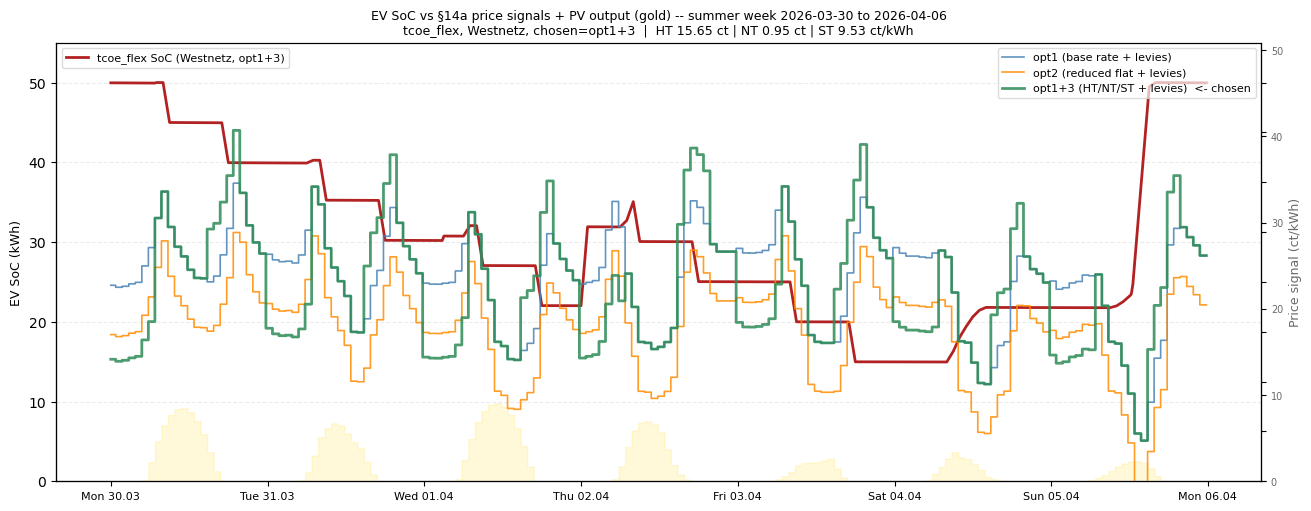

In [6]:
REF_DSO = 'Westnetz' if 'Westnetz' in schedules['tcoe_flex'] else next(iter(schedules['tcoe_flex']))
opt_tc  = schedules['tcoe_flex'][REF_DSO][3]
Eev_tc  = np.asarray(schedules['tcoe_flex'][REF_DSO][2], dtype=float)  # EV grid import
Ef_tc   = np.asarray(schedules['tcoe_flex'][REF_DSO][1], dtype=float)  # PV feed-in

# Reconstruct tcoe_flex SoC for visualisation
soc_tc_vis = _reconstruct_soc(Eev_tc, Ef_tc)

# Build all three §14a price signals for REF_DSO
dso_ref = dso_tariffs.loc[dso_tariffs['DSO'] == REF_DSO].iloc[0]
base_ap = float(dso_ref['Arbeitspreis_ct_kWh'])
mod2_ct = float(dso_ref['Module2_ct_kWh'])
ev_mod3 = build_ev_dso_rate_mod3(df['timestamp'], REF_DSO, dso_ref)
c_opt1  = spot_arr + base_ap + TAX_PRE_VAT
c_opt2  = spot_arr + mod2_ct  + TAX_PRE_VAT
c_opt13 = spot_arr + ev_mod3  + TAX_PRE_VAT

# Summer week: high PV -> PV self-consumption reduces EV grid import most clearly
pv_daily  = pd.Series(pv_arr, index=pd.to_datetime(df['timestamp'])).resample('D').sum()
sum_start = pd.Timestamp(pv_daily[pv_daily >= pv_daily.quantile(0.80)].index[0]).floor('D')
while sum_start.weekday() != 0:   # align to Monday for clean weekly x-axis
    sum_start += pd.Timedelta(days=1)
sum_end = sum_start + pd.Timedelta(days=7)
mask    = ((df['timestamp'] >= sum_start) & (df['timestamp'] < sum_end)).values
x       = pd.to_datetime(df.loc[mask, 'timestamp'])

# SoC arrays are length n+1 (boundary values); use start-of-slot alignment
soc_tc_plot = soc_tc_vis[:-1][mask]

fig, ax_soc = plt.subplots(1, 1, figsize=(13, 5), constrained_layout=True)

# Background: PV output (gold fill) on right axis to show when self-consumption is possible
ax_pv = ax_soc.twinx()
ax_pv.fill_between(x, 0, pv_arr[mask] * 4,   # kWh/slot -> kW
                   alpha=0.15, color='gold', step='pre', label='PV output (kW)')
ax_pv.set_ylabel('', color='goldenrod', fontsize=1)   # keep axis invisible
ax_pv.tick_params(axis='y', labelleft=False, labelright=False)
ax_pv.set_ylim(0, P_EV_max * 4)

# Right axis: three §14a price signals
ax_pr = ax_soc.twinx()
ax_pr.spines['right'].set_position(('outward', 0))
lw_13 = 2.0 if opt_tc == 'opt1+3' else 1.2
ax_pr.step(x, c_opt1[mask],  where='pre', lw=1.2, color='steelblue',  alpha=0.85,
           label='opt1 (base rate + levies)')
ax_pr.step(x, c_opt2[mask],  where='pre', lw=1.2, color='darkorange', alpha=0.85,
           label='opt2 (reduced flat + levies)')
ax_pr.step(x, c_opt13[mask], where='pre', lw=lw_13, color='seagreen', alpha=0.85,
           label=f'opt1+3 (HT/NT/ST + levies){"  <- chosen" if opt_tc == "opt1+3" else ""}')
ax_pr.set_ylabel('Price signal (ct/kWh)', fontsize=9, color='dimgrey')
ax_pr.tick_params(axis='y', labelcolor='dimgrey', labelsize=7)
ax_pr.set_ylim(0, max(c_opt1[mask].max(), c_opt13[mask].max()) * 1.25)
ax_pr.legend(loc='upper right', fontsize=8, framealpha=0.7)

# Left axis: tcoe_flex EV SoC
ax_soc.plot(x, soc_tc_plot, lw=2.0, color='firebrick',
            label=f'tcoe_flex SoC ({REF_DSO}, {opt_tc})')
ax_soc.set_ylabel('EV SoC (kWh)', fontsize=9)
ax_soc.set_ylim(0, E_EV_max * 1.1)
ax_soc.legend(loc='upper left', fontsize=8, framealpha=0.7)
ax_soc.grid(axis='y', linestyle='--', alpha=0.25)
ax_soc.spines[['top']].set_visible(False)

ax_soc.xaxis.set_major_formatter(mdates.DateFormatter('%a %d.%m'))
ax_soc.xaxis.set_major_locator(mdates.DayLocator())
ax_soc.tick_params(axis='x', labelsize=8, rotation=0)

ax_soc.set_title(
    f'EV SoC vs §14a price signals + PV output (gold) -- summer week {sum_start.date()} to {sum_end.date()}\n'
    f'tcoe_flex, {REF_DSO}, chosen={opt_tc}  |  '
    f'HT {dso_ref["HT_ct_kWh"]} ct | NT {dso_ref["NT_ct_kWh"]} ct | ST {dso_ref["ST_ct_kWh"]} ct/kWh',
    fontsize=9
)
plt.show()


## Step 6 — Billing

**Billing note for this archetype:** DSO volumetric cost is split into two streams:
- **Base import** (fixed by PV allocation) → always billed at base Arbeitspreis
- **EV grid import** (after PV self-use) → billed at the option-specific §14a rate

Spot cost is net of PV export revenue. Levies apply to total grid import.


In [7]:
results = []
for _, dso_row in dso_tariffs.iterrows():
    dso_id = str(dso_row['DSO'])
    for strategy in ('no_flex', 'dt_flex', 'tcoe_flex'):
        if strategy == 'tcoe_flex':
            _val = schedules['tcoe_flex'][dso_id]
            E_g, E_f, E_ev = np.asarray(_val[0]), np.asarray(_val[1]), np.asarray(_val[2])
            opt = _val[3]
        else:
            E_g, E_f, E_ev = [np.asarray(x) for x in schedules[strategy]]
            opt = 'opt1'

        base_ap  = float(dso_row['Arbeitspreis_ct_kWh'])
        mod1_eur = float(dso_row['Module1_rebate_EUR_year'])
        mod2_ct  = float(dso_row['Module2_ct_kWh'])

        cost_spot = (np.sum(E_g * spot_arr) - np.sum(E_f * spot_arr)) / 100.0
        cost_base_vol = np.sum(base_import) * base_ap / 100.0
        if opt == 'opt1':
            cost_ev_vol = np.sum(E_ev) * base_ap / 100.0
            cost_mod1   = mod1_eur
        elif opt == 'opt2':
            cost_ev_vol = np.sum(E_ev) * mod2_ct / 100.0
            cost_mod1   = 0.0
        else:
            ev_r = build_ev_dso_rate_mod3(ts_idx, dso_id, dso_row)
            cost_ev_vol = np.sum(E_ev * ev_r) / 100.0
            cost_mod1   = mod1_eur
        cost_dso_vol = cost_base_vol + cost_ev_vol + cost_mod1
        cost_lev     = np.sum(E_g) * TAX_PRE_VAT / 100.0
        cost_fixed   = float(dso_row['Grundpreis_EUR_year'])
        subtotal     = cost_spot + cost_dso_vol + cost_lev + cost_fixed + SMART_OP_EUR
        vat          = VAT_RATE * subtotal

        results.append({
            'strategy'                     : strategy,
            'household_archetype'          : 7,
            'dso_id'                       : dso_id,
            'annual_energy_kwh'            : round(float(np.sum(E_g)), 2),
            'annual_feedin_kwh'            : round(float(np.sum(E_f)), 2),
            'cost_spot_net_eur'            : round(cost_spot,    2),
            'cost_dso_volumetric_net_eur'  : round(cost_dso_vol, 2),
            'cost_dso_fixed_net_eur'       : round(cost_fixed,   2),
            'cost_smart_operating_net_eur' : round(SMART_OP_EUR, 2),
            'cost_14a_mod1_net_eur'        : round(cost_mod1,    2),
            'cost_levies_pre_vat_eur'      : round(cost_lev,     2),
            'subtotal_net_eur'             : round(subtotal,     2),
            'vat_eur'                      : round(vat,          2),
            'total_tcoe_eur'               : round(subtotal + vat, 2),
            'billing_14a_option'           : opt,
            'optimized_14a_option'         : opt if strategy == 'tcoe_flex' else None,
        })

results = pd.DataFrame(results)
assert results['total_tcoe_eur'].notna().all(), 'NaN in total_tcoe_eur'
print(f'TCoE range (all 21 runs): {results["total_tcoe_eur"].min():.2f} - {results["total_tcoe_eur"].max():.2f} EUR/year')
print(f'Winning §14a options (tcoe_flex): {results[results["strategy"]=="tcoe_flex"]["billing_14a_option"].value_counts().to_dict()}')
results


TCoE range (all 21 runs): 393.13 - 1381.13 EUR/year
Winning §14a options (tcoe_flex): {'opt1+3': 7}


,strategy,household_archetype,dso_id,annual_energy_kwh,annual_feedin_kwh,cost_spot_net_eur,cost_dso_volumetric_net_eur,cost_dso_fixed_net_eur,cost_smart_operating_net_eur,cost_14a_mod1_net_eur,cost_levies_pre_vat_eur,subtotal_net_eur,vat_eur,total_tcoe_eur,billing_14a_option,optimized_14a_option
0,no_flex,7,Westnetz,5933.08,9912.91,159.63,426.72,80.30,100.0,-138.70,393.96,1160.61,220.52,1381.13,opt1,None
1,dt_flex,7,Westnetz,5937.14,9893.95,-209.34,427.11,80.30,100.0,-138.70,394.23,792.30,150.54,942.83,opt1,None
2,tcoe_flex,7,Westnetz,3886.73,7873.35,-152.99,131.15,80.30,100.0,-138.70,258.08,416.54,79.14,495.68,opt1+3,opt1+3
3,no_flex,7,Bayernwerk,5933.08,9912.91,159.63,156.86,98.55,100.0,-123.18,393.96,909.00,172.71,1081.71,opt1,None
4,dt_flex,7,Bayernwerk,5937.14,9893.95,-209.34,157.05,98.55,100.0,-123.18,394.23,540.49,102.69,643.18,opt1,None
5,tcoe_flex,7,Bayernwerk,3925.61,7912.20,-163.65,55.75,98.55,100.0,-123.18,260.66,351.32,66.75,418.07,opt1+3,opt1+3
6,no_flex,7,E.DIS,5933.08,9912.91,159.63,216.29,76.65,100.0,-108.25,393.96,946.53,179.84,1126.37,opt1,None
7,dt_flex,7,E.DIS,5937.14,9893.95,-209.34,216.51,76.65,100.0,-108.25,394.23,578.05,109.83,687.88,opt1,None
8,tcoe_flex,7,E.DIS,3885.21,7871.77,-158.06,53.79,76.65,100.0,-108.25,257.98,330.36,62.77,393.13,opt1+3,opt1+3
9,no_flex,7,Netze BW,5933.08,9912.91,159.63,268.35,84.00,100.0,-180.78,393.96,1005.94,191.13,1197.07,opt1,None


## Step 7 — Summary and export

In [8]:
# Table 1: no_flex cost breakdown (reference -- comparable to Archetypes 1-6)
nf = (results[results['strategy'] == 'no_flex']
      [['dso_id', 'cost_spot_net_eur', 'cost_dso_volumetric_net_eur',
        'cost_14a_mod1_net_eur', 'cost_dso_fixed_net_eur',
        'cost_smart_operating_net_eur', 'cost_levies_pre_vat_eur',
        'vat_eur', 'total_tcoe_eur']]
      .set_index('dso_id')
      .rename(columns={
          'cost_spot_net_eur'               : 'Spot net (€)',
          'cost_dso_volumetric_net_eur'     : 'DSO vol (€)',
          'cost_14a_mod1_net_eur'           : '§14a Mod1 rebate (€)',
          'cost_dso_fixed_net_eur'          : 'DSO fix (€)',
          'cost_smart_operating_net_eur'    : 'Smart op. (€)',
          'cost_levies_pre_vat_eur'         : 'Levies pre-VAT (€)',
          'vat_eur'                         : 'VAT (€)',
          'total_tcoe_eur'                  : 'TCoE no_flex (€/yr)',
      }))

print(f'Annual: grid {E_grid_nf.sum():.1f} kWh  |  feed-in {E_feedin_nf.sum():.1f} kWh  '
      f'|  PV total {pv_arr.sum():.1f} kWh  |  EV driving {E_dem.sum():.1f} kWh')
print('\nTable 1 -- no_flex cost breakdown (reference, §14a opt1):')
display(nf)

# Table 2: strategy comparison + flex savings
piv = results.pivot_table(index='dso_id', columns='strategy',
                           values='total_tcoe_eur', aggfunc='first')
piv = piv[['no_flex', 'dt_flex', 'tcoe_flex']]
piv.columns.name = None
piv['saving dt_flex (€/yr)']   = piv['no_flex'] - piv['dt_flex']
piv['saving tcoe_flex (€/yr)'] = piv['no_flex'] - piv['tcoe_flex']
piv = piv.rename(columns={
    'no_flex'   : 'TCoE no_flex (€/yr)',
    'dt_flex'   : 'TCoE dt_flex (€/yr)',
    'tcoe_flex' : 'TCoE tcoe_flex (€/yr)',
})
print('\nTable 2 -- strategy comparison and flex savings vs no_flex:')
display(piv)

out = OUTPUTS / 'results_base_pv_ev_2026.csv'
results.to_csv(out, index=False)
print(f'\nSaved : {out}')
print(f'Rows  : {len(results)}  (3 strategies x 7 DSOs)')


Annual: grid 5933.1 kWh  |  feed-in 9912.9 kWh  |  PV total 11749.3 kWh  |  EV driving 2610.0 kWh

Table 1 -- no_flex cost breakdown (reference, §14a opt1):


,Spot net (€),DSO vol (€),§14a Mod1 rebate (€),DSO fix (€),Smart op. (€),Levies pre-VAT (€),VAT (€),TCoE no_flex (€/yr)
dso_id,,,,,,,,
Westnetz,159.63,426.72,-138.70,80.30,100.0,393.96,220.52,1381.13
Bayernwerk,159.63,156.86,-123.18,98.55,100.0,393.96,172.71,1081.71
E.DIS,159.63,216.29,-108.25,76.65,100.0,393.96,179.84,1126.37
Netze BW,159.63,268.35,-180.78,84.00,100.0,393.96,191.13,1197.07
Stromnetz Berlin,159.63,319.43,-123.18,33.36,100.0,393.96,191.21,1197.59
SH Netz,159.63,264.49,-115.23,94.90,100.0,393.96,192.47,1205.44
MITNETZ STROM,159.63,259.83,-114.55,73.00,100.0,393.96,187.42,1173.83



Table 2 -- strategy comparison and flex savings vs no_flex:


,TCoE no_flex (€/yr),TCoE dt_flex (€/yr),TCoE tcoe_flex (€/yr),saving dt_flex (€/yr),saving tcoe_flex (€/yr)
dso_id,,,,,
Bayernwerk,1081.71,643.18,418.07,438.53,663.64
E.DIS,1126.37,687.88,393.13,438.49,733.24
MITNETZ STROM,1173.83,735.39,415.53,438.44,758.30
Netze BW,1197.07,758.68,449.29,438.39,747.78
SH Netz,1205.44,767.00,434.58,438.44,770.86
Stromnetz Berlin,1197.59,759.19,411.59,438.40,786.00
Westnetz,1381.13,942.83,495.68,438.30,885.45



Saved : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/outputs/results_base_pv_ev_2026.csv
Rows  : 21  (3 strategies x 7 DSOs)
